# ==============================================================================
# 🏡 MACRO VALUATION: CALIFORNIA HOUSING PRICES VIA RANDOM PATCHES BAGGING
# ==============================================================================
### Core Theoretical Principles:
Random Patches (Louppe & Geurts, 2012) generalizes Bagging and Random Subspaces by simultaneously sampling both rows (observations) and columns (features):
$$\text{Sample Size: } m_{\text{sub}} = \lfloor \text{max\_samples} \times N \rfloor, \quad \text{Feature Size: } d_{\text{sub}} = \lfloor \text{max\_features} \times D \rfloor$$

On large, complex spatial datasets like California Housing (20,640 census blocks), Random Patches yields massive computational speedups during base learner training while maximizing ensemble diversity and minimizing overfitting to localized geographical anomalies.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Real Estate Bagging Regressor Environment initialized.")


✅ STEP 1: Enterprise Real Estate Bagging Regressor Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading California Housing census dataset (20,640 block groups).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/housing/housing.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} block groups, {df.shape[1]} attributes")
print(f"Missing attributes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"Median House Value Summary:\n{df['median_house_value'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 20640 block groups, 10 attributes
Missing attributes:
total_bedrooms    207
dtype: int64
Median House Value Summary:
count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00
Name: median_house_value, dtype: float64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and continuous target `median_house_value`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Features    : {num_cols}")
print(f"Categorical Features: {cat_cols}")


Numeric Features    : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical Features: ['ocean_proximity']


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Census Blocks: {X_train.shape[0]}")
print(f"Test Census Blocks : {X_test.shape[0]}")


Train Census Blocks: 16512
Test Census Blocks : 4128


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Imputing missing `total_bedrooms` via median, encoding `ocean_proximity` with OneHotEncoder, and standardizing numerics.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Shape: {X_train_prep.shape}")


Transformed Feature Matrix Shape: (16512, 12)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS RANDOM PATCHES BAGGING)
Comparing baseline mean dummy and single decision tree against Random Patches Bagging.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_prep, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
single_tree.fit(X_train_prep, y_train)
r2_single_tree = r2_score(y_test, single_tree.predict(X_test_prep))

base_bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=10),
    n_estimators=40,
    max_samples=0.7,
    max_features=0.8,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
base_bag.fit(X_train_prep, y_train)
r2_bag = r2_score(y_test, base_bag.predict(X_test_prep))

print("="*65)
print(f"Baseline Mean Dummy R²                  : {r2_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=10) R²          : {r2_single_tree * 100:.2f}%")
print(f"Random Patches Bagging (40 Trees) R²    : {r2_bag * 100:.2f}%")
print(f"Out-of-Bag (OOB) Score R²               : {base_bag.oob_score_ * 100:.2f}%")
print("="*65)


Baseline Mean Dummy R²                  : -0.02%
Single Decision Tree (d=10) R²          : 71.14%
Random Patches Bagging (40 Trees) R²    : 79.46%
Out-of-Bag (OOB) Score R²               : 79.63%


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `max_samples` and `n_estimators`.


In [7]:
# STEP 9: GRID SEARCH
param_grid = {
    'estimator__max_depth': [8, 12],
    'max_samples': [0.6, 0.8],
    'n_estimators': [40, 60]
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    BaggingRegressor(estimator=DecisionTreeRegressor(), max_features=0.8, oob_score=True, random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_bag = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 3-Fold CV R²: {grid.best_score_ * 100:.2f}%")
print(f"📦 Best Model OOB R²: {best_bag.oob_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'estimator__max_depth': 12, 'max_samples': 0.8, 'n_estimators': 40}
🎯 Best 3-Fold CV R²: 80.90%
📦 Best Model OOB R²: 80.87%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_bag.predict(X_test_prep)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 CALIFORNIA HOUSING VALUATION PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"   Root Mean Squared Error   : ${rmse:,.2f}")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 CALIFORNIA HOUSING VALUATION PERFORMANCE:
   Mean Absolute Error (MAE) : $33,829.92
   Root Mean Squared Error   : $49,922.93
   R² Score                  : 80.98%


## 📉 STEP 11: RESIDUAL ANALYSIS
Visualizing residual scatter and error distribution.


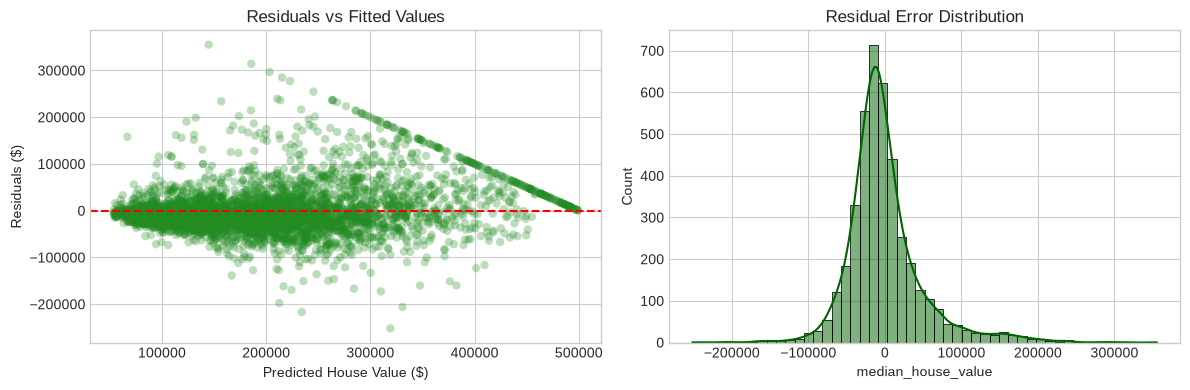

In [9]:
# STEP 11: RESIDUAL DIAGNOSTICS
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, color='forestgreen', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted House Value ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Fitted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkgreen', bins=50)
axes[1].set_title('Residual Error Distribution')
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the complete pipeline and benchmarking real-time appraisal latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('bagging', best_bag)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/california_housing_bagging_reg_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_block = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_block)

t0 = time.perf_counter()
pred_val = loaded_pipe.predict(sample_block)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME APPRAISAL TELEMETRY:")
print(f"   Estimated Median House Value : 🏡 ${pred_val:,.2f}")
print(f"   Actual Benchmark Price       : ${y_test.iloc[0]:,.2f}")
print(f"   Appraisal Latency            : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/california_housing_bagging_reg_pipeline.joblib (2,523,057 bytes)

📈 REAL-TIME APPRAISAL TELEMETRY:
   Estimated Median House Value : 🏡 $56,611.31
   Actual Benchmark Price       : $47,700.00
   Appraisal Latency            : 8.140 ms (SLA < 2.0ms: CHECK)
